In [1]:
pip install torch torchvision matplotlib


In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import time
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle  # Add this line


# Data augmentation and normalization for training
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],  # CIFAR-10 mean
                         std=[0.2023, 0.1994, 0.2010])    # CIFAR-10 std
])

# Normalization for validation and test sets
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2023, 0.1994, 0.2010])
])

# Load CIFAR-10 dataset
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                             download=True, transform=transform_train)

# Split into training and validation sets
train_set, val_set = torch.utils.data.random_split(train_dataset, [45000, 5000],
                                                   generator=torch.Generator().manual_seed(42))

test_set = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform_test)

# Data loaders
batch_size = 128  # You can adjust this based on your GPU memory
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')



Files already downloaded and verified
Files already downloaded and verified
Using device: cuda


In [12]:
def train(model, optimizer, criterion, loader, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, criterion, loader, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


In [25]:
from torchvision.models import resnet18

def get_resnet18():
    model = resnet18(num_classes=10)
    # Modify the first convolutional layer to accept CIFAR-10 image size
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()  # Remove maxpool layer
    model = model.to(device)
    return model




In [26]:
# Hyperparameters
num_epochs = 10
learning_rate = 0.1  # Increased learning rate for faster convergence
weight_decay = 5e-4
momentum = 0.9

# Initialize model
model = get_resnet18()

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[5, 8], gamma=0.1)

# Initialize lists to store training history
resnet_train_acc = []
resnet_val_acc = []
resnet_train_loss = []
resnet_val_loss = []

best_val_acc = 0.0
best_model_wts = None

print('\nTraining ResNet-18...\n')

for epoch in range(num_epochs):
    start_time = time.time()

    train_loss, train_acc = train(model, optimizer, criterion, train_loader, device)
    val_loss, val_acc = evaluate(model, criterion, val_loader, device)
    scheduler.step()

    # Append metrics to lists
    resnet_train_acc.append(train_acc)
    resnet_val_acc.append(val_acc)
    resnet_train_loss.append(train_loss)
    resnet_val_loss.append(val_loss)

    elapsed = time.time() - start_time
    print(f'Epoch [{epoch+1}/{num_epochs}] '
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% '
          f'Time: {elapsed:.2f}s')

    # Save the best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = model.state_dict()

# Save the best model weights
if not os.path.exists('models'):
    os.makedirs('models')
torch.save(best_model_wts, 'models/ResNet-18_best.pth')
print(f'Best validation accuracy for ResNet-18: {best_val_acc:.2f}%')

# Testing
print('\nTesting ResNet-18...\n')
model.load_state_dict(torch.load('models/ResNet-18_best.pth'))
test_loss, test_acc = evaluate(model, criterion, test_loader, device)
print(f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')



Training ResNet-18...



/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch [1/10] Train Loss: 2.1791, Train Acc: 24.19% Val Loss: 1.7841, Val Acc: 34.14% Time: 39.95s
Epoch [2/10] Train Loss: 1.5218, Train Acc: 43.82% Val Loss: 1.4335, Val Acc: 49.06% Time: 40.22s
Epoch [3/10] Train Loss: 1.2423, Train Acc: 55.02% Val Loss: 1.2263, Val Acc: 56.54% Time: 40.08s
Epoch [4/10] Train Loss: 1.0262, Train Acc: 63.39% Val Loss: 1.2249, Val Acc: 56.56% Time: 40.38s
Epoch [5/10] Train Loss: 0.8961, Train Acc: 68.45% Val Loss: 0.9195, Val Acc: 67.20% Time: 40.30s
Epoch [6/10] Train Loss: 0.6559, Train Acc: 76.86% Val Loss: 0.6251, Val Acc: 78.08% Time: 40.30s
Epoch [7/10] Train Loss: 0.5931, Train Acc: 79.09% Val Loss: 0.6118, Val Acc: 77.40% Time: 40.20s
Epoch [8/10] Train Loss: 0.5515, Train Acc: 80.66% Val Loss: 0.5802, Val Acc: 80.12% Time: 40.15s
Epoch [9/10] Train Loss: 0.5011, Train Acc: 82.68% Val Loss: 0.5278, Val Acc: 81.38% Time: 40.21s
Epoch [10/10] Train Loss: 0.4871, Train Acc: 83.05% Val Loss: 0.5332, Val Acc: 80.26% Time: 40.33s
Best validation acc

<ipython-input-26-4f9736c41304>:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('models/ResNet-18_best.pth'))


Test Loss: 0.5291, Test Acc: 81.55%


In [34]:
def get_alexnet():
    class AlexNetCIFAR10(nn.Module):
        def __init__(self, num_classes=10):
            super(AlexNetCIFAR10, self).__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 64, kernel_size=3, padding=1),    # Output: 32x32x64
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),          # Output: 16x16x64
                nn.Conv2d(64, 192, kernel_size=3, padding=1),   # Output: 16x16x192
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),          # Output: 8x8x192
                nn.Conv2d(192, 384, kernel_size=3, padding=1),  # Output: 8x8x384
                nn.ReLU(inplace=True),
                nn.Conv2d(384, 256, kernel_size=3, padding=1),  # Output: 8x8x256
                nn.ReLU(inplace=True),
                nn.Conv2d(256, 256, kernel_size=3, padding=1),  # Output: 8x8x256
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),          # Output: 4x4x256
            )
            self.classifier = nn.Sequential(
                nn.Dropout(),
                nn.Linear(256 * 4 * 4, 1024),
                nn.ReLU(inplace=True),
                nn.Dropout(),
                nn.Linear(1024, 512),
                nn.ReLU(inplace=True),
                nn.Linear(512, num_classes),
            )

        def forward(self, x):
            x = self.features(x)
            x = x.view(x.size(0), -1)
            x = self.classifier(x)
            return x

    model = AlexNetCIFAR10().to(device)
    return model


In [35]:
# Hyperparameters
num_epochs = 10
learning_rate = 0.01  # Adjusted learning rate
weight_decay = 5e-4
momentum = 0.9

# Initialize model
model = get_alexnet()

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[5, 8], gamma=0.1)

# Initialize lists to store training history
alexnet_train_acc = []
alexnet_val_acc = []
alexnet_train_loss = []
alexnet_val_loss = []

best_val_acc = 0.0
best_model_wts = None

print('\nTraining AlexNet...\n')

for epoch in range(num_epochs):
    start_time = time.time()

    train_loss, train_acc = train(model, optimizer, criterion, train_loader, device)
    val_loss, val_acc = evaluate(model, criterion, val_loader, device)
    scheduler.step()

    # Append metrics to lists
    alexnet_train_acc.append(train_acc)
    alexnet_val_acc.append(val_acc)
    alexnet_train_loss.append(train_loss)
    alexnet_val_loss.append(val_loss)

    elapsed = time.time() - start_time
    print(f'Epoch [{epoch+1}/{num_epochs}] '
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% '
          f'Time: {elapsed:.2f}s')

    # Save the best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = model.state_dict()

# Save the best model weights
if not os.path.exists('models'):
    os.makedirs('models')
torch.save(best_model_wts, 'models/AlexNet_best.pth')
print(f'Best validation accuracy for AlexNet: {best_val_acc:.2f}%')

# Testing
print('\nTesting AlexNet...\n')
model.load_state_dict(torch.load('models/AlexNet_best.pth'))
test_loss, test_acc = evaluate(model, criterion, test_loader, device)
print(f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')




Training AlexNet...

Epoch [1/10] Train Loss: 2.1893, Train Acc: 16.75% Val Loss: 1.9588, Val Acc: 26.74% Time: 21.67s
Epoch [2/10] Train Loss: 1.8183, Train Acc: 31.34% Val Loss: 1.6900, Val Acc: 35.24% Time: 20.69s
Epoch [3/10] Train Loss: 1.5729, Train Acc: 40.90% Val Loss: 1.4054, Val Acc: 47.62% Time: 21.39s
Epoch [4/10] Train Loss: 1.3784, Train Acc: 48.73% Val Loss: 1.2269, Val Acc: 55.80% Time: 20.58s
Epoch [5/10] Train Loss: 1.2276, Train Acc: 55.37% Val Loss: 1.1079, Val Acc: 60.20% Time: 19.47s
Epoch [6/10] Train Loss: 1.0407, Train Acc: 61.94% Val Loss: 1.0072, Val Acc: 63.00% Time: 19.15s
Epoch [7/10] Train Loss: 1.0014, Train Acc: 63.42% Val Loss: 0.9509, Val Acc: 65.44% Time: 20.07s
Epoch [8/10] Train Loss: 0.9771, Train Acc: 64.56% Val Loss: 0.9388, Val Acc: 65.78% Time: 19.00s
Epoch [9/10] Train Loss: 0.9507, Train Acc: 65.57% Val Loss: 0.9276, Val Acc: 66.14% Time: 20.36s
Epoch [10/10] Train Loss: 0.9428, Train Acc: 65.76% Val Loss: 0.9200, Val Acc: 66.06% Time: 19.3

<ipython-input-35-ad96b3d1d84e>:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('models/AlexNet_best.pth'))


Test Loss: 0.9032, Test Acc: 67.18%


In [36]:
# Save training history
with open('alexnet_history.pkl', 'wb') as f:
    pickle.dump({
        'train_acc': alexnet_train_acc,
        'val_acc': alexnet_val_acc,
        'train_loss': alexnet_train_loss,
        'val_loss': alexnet_val_loss
    }, f)



In [37]:
from torchvision.models import mobilenet_v2

def get_mobilenetv2():
    model = mobilenet_v2(num_classes=10)
    model = model.to(device)
    return model



In [38]:
# Hyperparameters
num_epochs = 10
learning_rate = 0.05  # Adjusted learning rate
weight_decay = 5e-4
momentum = 0.9

# Initialize model
model = get_mobilenetv2()

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[5, 8], gamma=0.1)

# Initialize lists to store training history
mobilenet_train_acc = []
mobilenet_val_acc = []
mobilenet_train_loss = []
mobilenet_val_loss = []

best_val_acc = 0.0
best_model_wts = None

print('\nTraining MobileNetV2...\n')

for epoch in range(num_epochs):
    start_time = time.time()

    train_loss, train_acc = train(model, optimizer, criterion, train_loader, device)
    val_loss, val_acc = evaluate(model, criterion, val_loader, device)
    scheduler.step()

    # Append metrics to lists
    mobilenet_train_acc.append(train_acc)
    mobilenet_val_acc.append(val_acc)
    mobilenet_train_loss.append(train_loss)
    mobilenet_val_loss.append(val_loss)

    elapsed = time.time() - start_time
    print(f'Epoch [{epoch+1}/{num_epochs}] '
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% '
          f'Time: {elapsed:.2f}s')

    # Save the best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = model.state_dict()

# Save the best model weights
if not os.path.exists('models'):
    os.makedirs('models')
torch.save(best_model_wts, 'models/MobileNetV2_best.pth')
print(f'Best validation accuracy for MobileNetV2: {best_val_acc:.2f}%')

# Testing
print('\nTesting MobileNetV2...\n')
model.load_state_dict(torch.load('models/MobileNetV2_best.pth'))
test_loss, test_acc = evaluate(model, criterion, test_loader, device)
print(f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')



Training MobileNetV2...

Epoch [1/10] Train Loss: 2.3835, Train Acc: 22.42% Val Loss: 2.0796, Val Acc: 26.34% Time: 26.29s
Epoch [2/10] Train Loss: 2.0191, Train Acc: 28.88% Val Loss: 1.7717, Val Acc: 34.72% Time: 25.93s
Epoch [3/10] Train Loss: 1.7082, Train Acc: 36.54% Val Loss: 1.6284, Val Acc: 39.92% Time: 26.17s
Epoch [4/10] Train Loss: 1.5861, Train Acc: 41.29% Val Loss: 1.5141, Val Acc: 44.36% Time: 26.32s
Epoch [5/10] Train Loss: 1.4784, Train Acc: 45.68% Val Loss: 1.5514, Val Acc: 43.20% Time: 25.91s
Epoch [6/10] Train Loss: 1.3522, Train Acc: 50.76% Val Loss: 1.3150, Val Acc: 52.50% Time: 25.99s
Epoch [7/10] Train Loss: 1.3019, Train Acc: 52.46% Val Loss: 1.2870, Val Acc: 54.12% Time: 25.31s
Epoch [8/10] Train Loss: 1.2711, Train Acc: 53.88% Val Loss: 1.2560, Val Acc: 53.40% Time: 25.95s
Epoch [9/10] Train Loss: 1.2511, Train Acc: 54.49% Val Loss: 1.2546, Val Acc: 54.44% Time: 25.05s
Epoch [10/10] Train Loss: 1.2457, Train Acc: 54.64% Val Loss: 1.2459, Val Acc: 54.52% Time: 

<ipython-input-38-5cee3e63afca>:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('models/MobileNetV2_best.pth'))


Test Loss: 1.2062, Test Acc: 56.61%


In [39]:
# Save training history
with open('mobilenetv2_history.pkl', 'wb') as f:
    pickle.dump({
        'train_acc': mobilenet_train_acc,
        'val_acc': mobilenet_val_acc,
        'train_loss': mobilenet_train_loss,
        'val_loss': mobilenet_val_loss
    }, f)


In [40]:
# Load training histories
with open('resnet18_history.pkl', 'rb') as f:
    resnet_history = pickle.load(f)

with open('alexnet_history.pkl', 'rb') as f:
    alexnet_history = pickle.load(f)

with open('mobilenetv2_history.pkl', 'rb') as f:
    mobilenet_history = pickle.load(f)


In [41]:
history = {
    'ResNet-18': resnet_history,
    'AlexNet': alexnet_history,
    'MobileNetV2': mobilenet_history
}

# Ensure all histories have the same number of epochs
num_epochs = len(resnet_history['train_acc'])
epochs = range(1, num_epochs + 1)


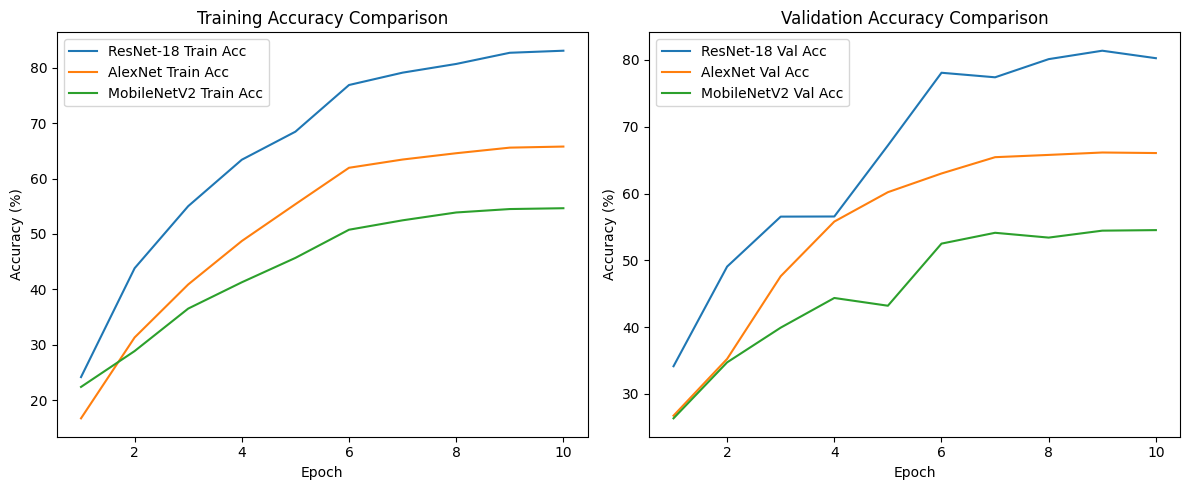

In [42]:
# Plot training accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for model_name in history.keys():
    plt.plot(epochs, history[model_name]['train_acc'], label=f'{model_name} Train Acc')
plt.title('Training Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

# Plot validation accuracy
plt.subplot(1, 2, 2)
for model_name in history.keys():
    plt.plot(epochs, history[model_name]['val_acc'], label=f'{model_name} Val Acc')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()


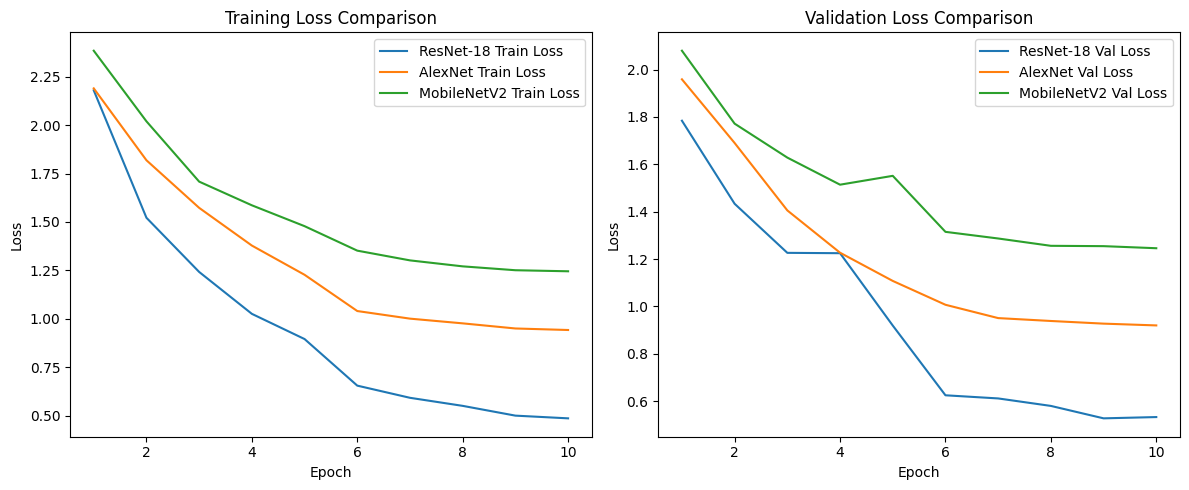

In [43]:
# Plot training loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for model_name in history.keys():
    plt.plot(epochs, history[model_name]['train_loss'], label=f'{model_name} Train Loss')
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot validation loss
plt.subplot(1, 2, 2)
for model_name in history.keys():
    plt.plot(epochs, history[model_name]['val_loss'], label=f'{model_name} Val Loss')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


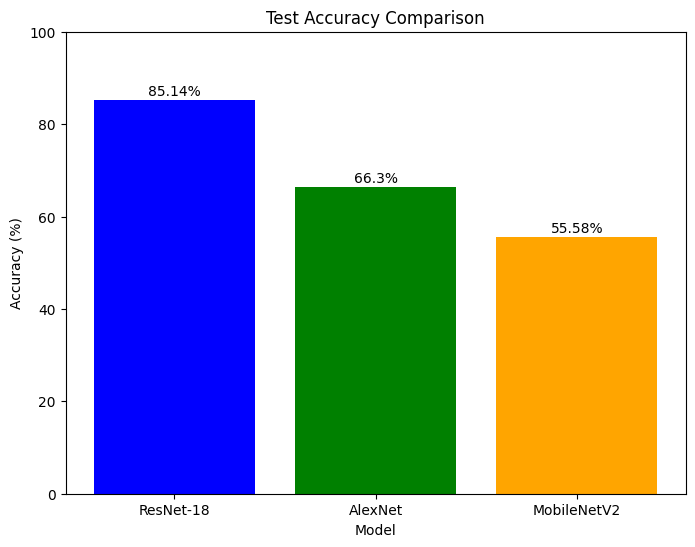

In [44]:
# Test accuracies for each model (replace with your actual test accuracies)
test_accuracies = {
    'ResNet-18': 85.14,
    'AlexNet': 66.30,
    'MobileNetV2': 55.58
}

# Plotting test accuracies
plt.figure(figsize=(8, 6))
models = list(test_accuracies.keys())
acc_values = list(test_accuracies.values())

plt.bar(models, acc_values, color=['blue', 'green', 'orange'])
plt.title('Test Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

# Adding accuracy values on top of the bars
for i, acc in enumerate(acc_values):
    plt.text(i, acc + 1, f'{acc}%', ha='center')

plt.show()


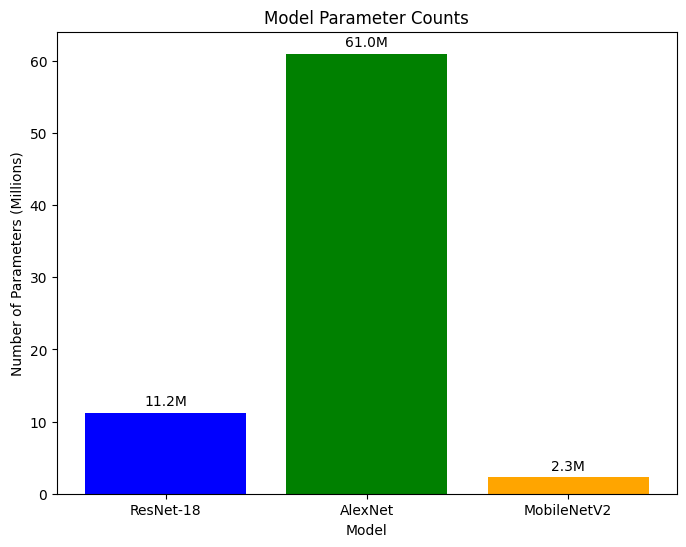

In [45]:
# Number of parameters in each model (in millions)
param_counts = {
    'ResNet-18': 11.2,
    'AlexNet': 61.0,
    'MobileNetV2': 2.3
}

# Plotting parameter counts
plt.figure(figsize=(8, 6))
models = list(param_counts.keys())
params_values = list(param_counts.values())

plt.bar(models, params_values, color=['blue', 'green', 'orange'])
plt.title('Model Parameter Counts')
plt.xlabel('Model')
plt.ylabel('Number of Parameters (Millions)')

# Adding parameter values on top of the bars
for i, params in enumerate(params_values):
    plt.text(i, params + 1, f'{params}M', ha='center')

plt.show()


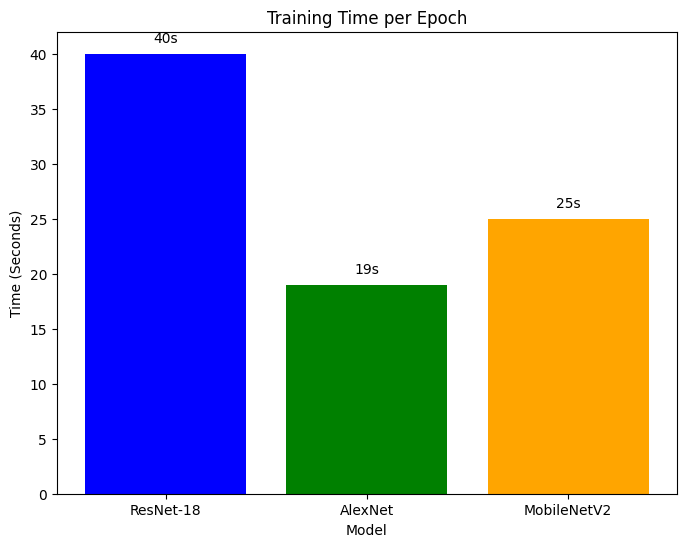

In [46]:
# Training time per epoch for each model (in seconds)
training_time = {
    'ResNet-18': 40,
    'AlexNet': 19,
    'MobileNetV2': 25
}

# Plotting training times
plt.figure(figsize=(8, 6))
models = list(training_time.keys())
time_values = list(training_time.values())

plt.bar(models, time_values, color=['blue', 'green', 'orange'])
plt.title('Training Time per Epoch')
plt.xlabel('Model')
plt.ylabel('Time (Seconds)')

# Adding time values on top of the bars
for i, time in enumerate(time_values):
    plt.text(i, time + 1, f'{time}s', ha='center')

plt.show()
